# Taller - Análisis de Figuras Geométricas: Centroide, Área y Perímetro

**Objetivo:** Detectar formas simples (círculos, cuadrados, triángulos) en imágenes binarizadas y calcular propiedades geométricas como área, perímetro y centroide.

## 1. Importar librerías

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Directorio de salida para guardar resultados
OUTPUT_DIR = os.path.join('..', 'media')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Librerías importadas correctamente')
print(f'OpenCV version: {cv2.__version__}')

Librerías importadas correctamente
OpenCV version: 4.13.0


## 2. Generar imagen sintética con figuras geométricas

Se genera una imagen en blanco con figuras básicas: círculo, cuadrado y triángulo.

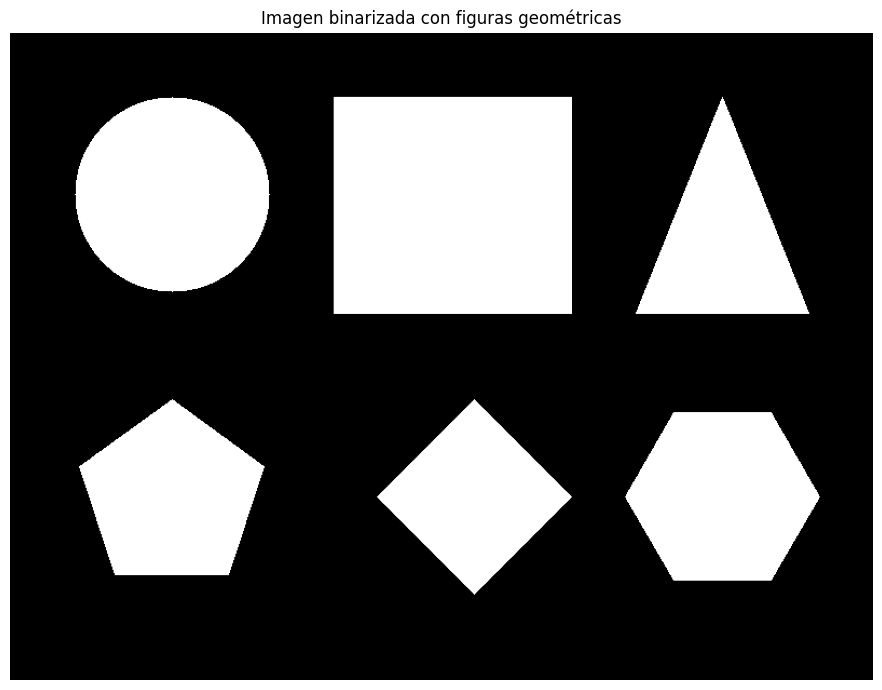

Imagen guardada: 01_imagen_binarizada.png


In [2]:
def create_synthetic_image(height=600, width=800):
    """Genera una imagen con un círculo, cuadrado y triángulo."""
    img = np.zeros((height, width), dtype=np.uint8)

    # Círculo
    cv2.circle(img, (150, 150), 90, 255, -1)

    # Cuadrado
    cv2.rectangle(img, (300, 60), (520, 260), 255, -1)

    # Triángulo
    pts = np.array([[660, 60], [580, 260], [740, 260]], dtype=np.int32)
    cv2.fillPoly(img, [pts], 255)

    # Pentágono (bonus)
    n = 5
    cx, cy, r = 150, 430, 90
    angles = [2 * np.pi * i / n - np.pi / 2 for i in range(n)]
    pentagon = np.array(
        [[int(cx + r * np.cos(a)), int(cy + r * np.sin(a))] for a in angles],
        dtype=np.int32
    )
    cv2.fillPoly(img, [pentagon], 255)

    # Rombo (diamante)
    diamond = np.array([[430, 340], [520, 430], [430, 520], [340, 430]], dtype=np.int32)
    cv2.fillPoly(img, [diamond], 255)

    # Hexágono
    n = 6
    cx, cy, r = 660, 430, 90
    angles = [2 * np.pi * i / n for i in range(n)]
    hexagon = np.array(
        [[int(cx + r * np.cos(a)), int(cy + r * np.sin(a))] for a in angles],
        dtype=np.int32
    )
    cv2.fillPoly(img, [hexagon], 255)

    return img


# Crear imagen y mostrarla
binary_img = create_synthetic_image()

plt.figure(figsize=(10, 7))
plt.imshow(binary_img, cmap='gray')
plt.title('Imagen binarizada con figuras geométricas')
plt.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '01_imagen_binarizada.png'), dpi=150)
plt.show()
print('Imagen guardada: 01_imagen_binarizada.png')

## 3. Detección de contornos con `cv2.findContours`

In [3]:
# Detectar contornos en la imagen binarizada
contours, hierarchy = cv2.findContours(
    binary_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
)

print(f'Número de contornos detectados: {len(contours)}')
for i, cnt in enumerate(contours):
    print(f'  Contorno {i}: {len(cnt)} puntos')

Número de contornos detectados: 6
  Contorno 0: 266 puntos
  Contorno 1: 4 puntos
  Contorno 2: 231 puntos
  Contorno 3: 323 puntos
  Contorno 4: 4 puntos
  Contorno 5: 260 puntos


## 4. Calcular propiedades geométricas

Para cada contorno se calcula: **área**, **perímetro** y **centroide** usando momentos.

In [4]:
def classify_shape(contour):
    """Clasifica la figura según el número de vértices tras aproximación poligonal."""
    epsilon = 0.04 * cv2.arcLength(contour, True)
    approx = cv2.approxPolyDP(contour, epsilon, True)
    vertices = len(approx)

    labels = {
        3: 'Triangulo',
        4: 'Cuadrado/Rombo',
        5: 'Pentagono',
        6: 'Hexagono',
    }
    return labels.get(vertices, 'Circulo' if vertices > 8 else f'Poligono({vertices})')


def compute_properties(contour):
    """Calcula área, perímetro y centroide de un contorno."""
    area = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, True)

    M = cv2.moments(contour)
    if M['m00'] != 0:
        cx = int(M['m10'] / M['m00'])
        cy = int(M['m01'] / M['m00'])
    else:
        cx, cy = 0, 0

    shape = classify_shape(contour)
    return {'area': area, 'perimeter': perimeter, 'centroid': (cx, cy), 'shape': shape}


# Calcular propiedades para todos los contornos
properties = [compute_properties(cnt) for cnt in contours]

print(f"{'#':<4} {'Figura':<18} {'Área':>10} {'Perímetro':>12} {'Centroide'}")
print('-' * 65)
for i, prop in enumerate(properties):
    cx, cy = prop['centroid']
    print(f"{i:<4} {prop['shape']:<18} {prop['area']:>10.1f} {prop['perimeter']:>12.1f} ({cx}, {cy})")

#    Figura                   Área    Perímetro Centroide
-----------------------------------------------------------------
0    Hexagono              20925.0        564.6 (659, 429)
1    Cuadrado/Rombo        16200.0        509.1 (430, 430)
2    Pentagono             19101.0        554.7 (149, 429)
3    Triangulo             16000.0        626.3 (660, 193)
4    Cuadrado/Rombo        44000.0        840.0 (410, 160)
5    Poligono(8)           25190.0        595.8 (150, 150)


## 5. Visualizar contornos con etiquetas de métricas

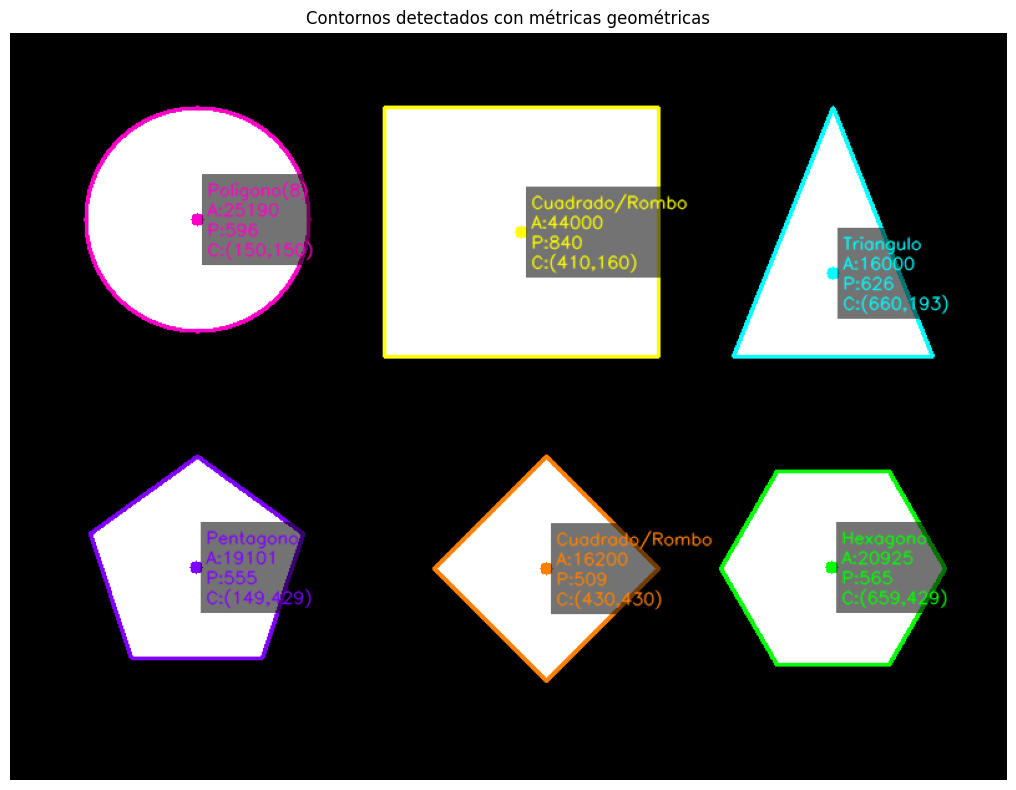

Imagen guardada: 02_contornos_con_metricas.png


In [5]:
# Crear imagen RGB a color para dibujar los contornos
display_img = cv2.cvtColor(binary_img, cv2.COLOR_GRAY2BGR)

COLORS = [
    (0, 255, 0),    # verde
    (0, 128, 255),  # naranja
    (255, 0, 128),  # rosa
    (255, 255, 0),  # amarillo
    (0, 255, 255),  # cian
    (200, 0, 255),  # violeta
]

for i, (cnt, prop) in enumerate(zip(contours, properties)):
    color = COLORS[i % len(COLORS)]
    cx, cy = prop['centroid']

    # Dibujar contorno
    cv2.drawContours(display_img, [cnt], -1, color, 2)

    # Marcar centroide
    cv2.circle(display_img, (cx, cy), 5, color, -1)

    # Etiquetas (fondo semitransparente)
    label_lines = [
        prop['shape'],
        f"A:{prop['area']:.0f}",
        f"P:{prop['perimeter']:.0f}",
        f"C:({cx},{cy})",
    ]

    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 0.45
    thickness = 1
    line_height = 16
    margin = 4

    # Calcular tamaño del bloque de texto
    max_w = max(cv2.getTextSize(l, font, font_scale, thickness)[0][0] for l in label_lines)
    block_h = line_height * len(label_lines) + margin * 2

    tx = cx + 8
    ty = cy - block_h // 2

    # Fondo oscuro
    overlay = display_img.copy()
    cv2.rectangle(overlay, (tx - margin, ty), (tx + max_w + margin, ty + block_h), (0, 0, 0), -1)
    cv2.addWeighted(overlay, 0.55, display_img, 0.45, 0, display_img)

    for j, line in enumerate(label_lines):
        cv2.putText(
            display_img, line,
            (tx, ty + margin + line_height * (j + 1) - 3),
            font, font_scale, color, thickness, cv2.LINE_AA
        )

# Mostrar resultado
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB))
plt.title('Contornos detectados con métricas geométricas')
plt.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '02_contornos_con_metricas.png'), dpi=150)
plt.show()
print('Imagen guardada: 02_contornos_con_metricas.png')

## 6. Clasificación automática de figuras (Bonus)

Se usa `cv2.approxPolyDP()` para aproximar cada contorno a un polígono y clasificar la figura.

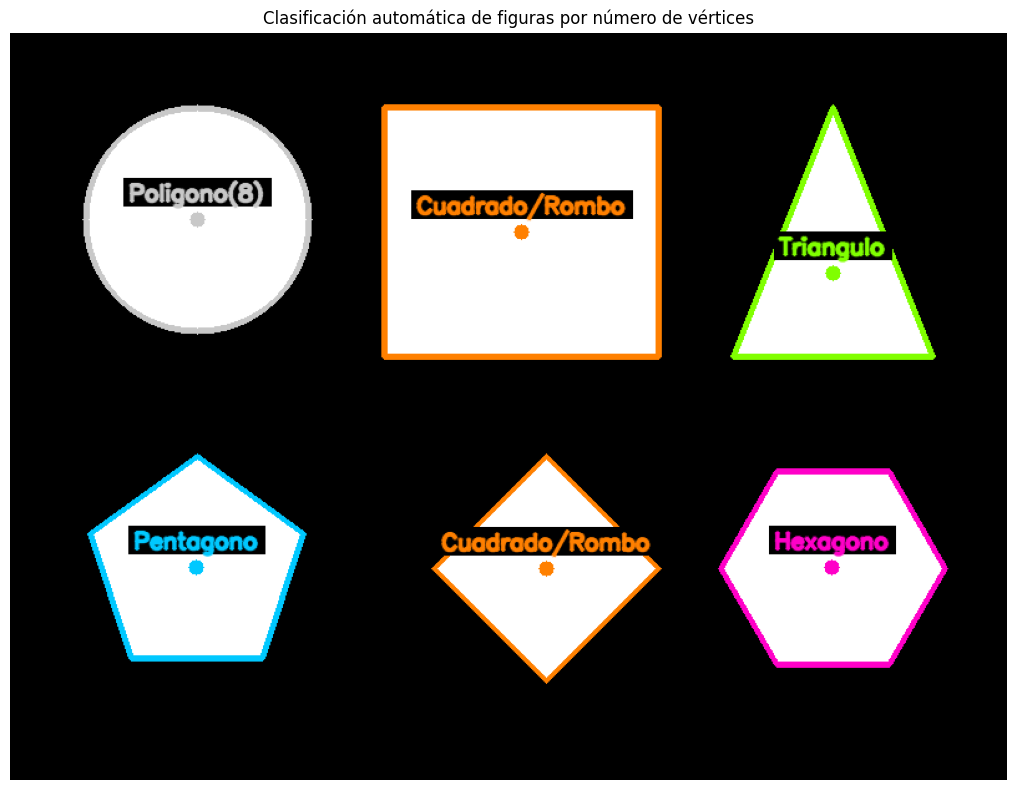

Imagen guardada: 03_clasificacion_figuras.png


In [6]:
# Imagen RGB fresca para el bonus
classified_img = cv2.cvtColor(binary_img, cv2.COLOR_GRAY2BGR)

SHAPE_COLORS = {
    'Triangulo':       (0, 255, 128),
    'Cuadrado/Rombo':  (0, 128, 255),
    'Pentagono':       (255, 200, 0),
    'Hexagono':        (200, 0, 255),
    'Circulo':         (0, 255, 255),
}
DEFAULT_COLOR = (200, 200, 200)

for cnt, prop in zip(contours, properties):
    shape_name = prop['shape']
    color = SHAPE_COLORS.get(shape_name, DEFAULT_COLOR)
    cx, cy = prop['centroid']

    # Dibujar contorno y centroide
    cv2.drawContours(classified_img, [cnt], -1, color, 3)
    cv2.circle(classified_img, (cx, cy), 6, color, -1)

    # Etiqueta de clasificación
    font = cv2.FONT_HERSHEY_SIMPLEX
    (tw, th), _ = cv2.getTextSize(shape_name, font, 0.6, 2)
    tx = cx - tw // 2
    ty = cy - 15

    cv2.rectangle(classified_img, (tx - 4, ty - th - 4), (tx + tw + 4, ty + 4), (0, 0, 0), -1)
    cv2.putText(classified_img, shape_name, (tx, ty), font, 0.6, color, 2, cv2.LINE_AA)

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(classified_img, cv2.COLOR_BGR2RGB))
plt.title('Clasificación automática de figuras por número de vértices')
plt.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '03_clasificacion_figuras.png'), dpi=150)
plt.show()
print('Imagen guardada: 03_clasificacion_figuras.png')

## 7. Análisis comparativo con gráfica de barras

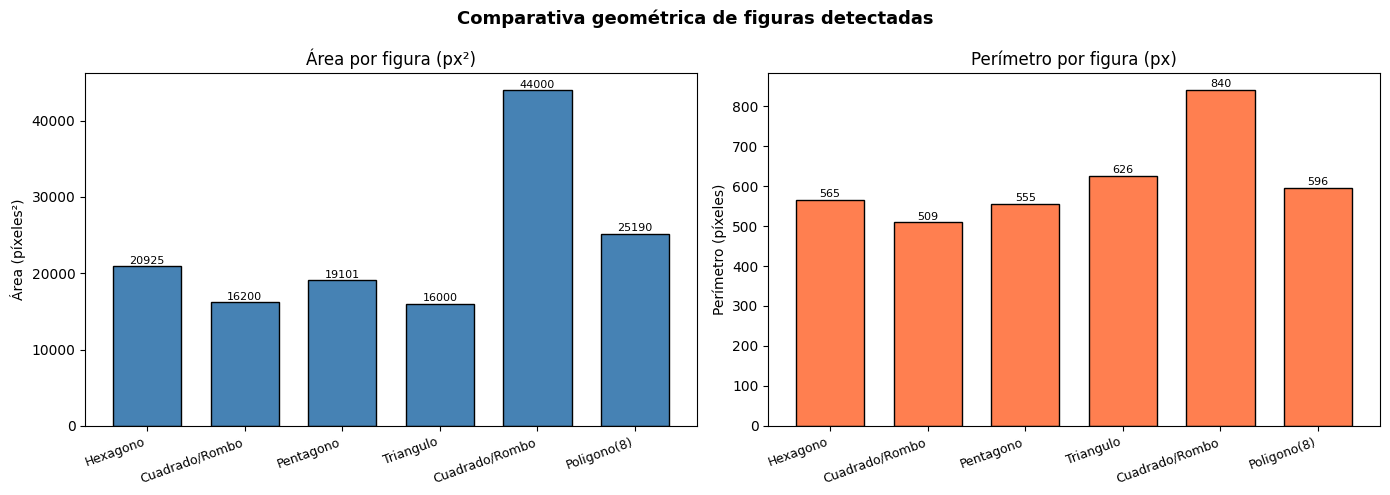

Imagen guardada: 04_comparativa_geometrica.png


In [7]:
shapes = [p['shape'] for p in properties]
areas  = [p['area'] for p in properties]
perims = [p['perimeter'] for p in properties]

x = np.arange(len(shapes))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Área ---
bars1 = axes[0].bar(x, areas, width * 2, color='steelblue', edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(shapes, rotation=20, ha='right', fontsize=9)
axes[0].set_title('Área por figura (px²)')
axes[0].set_ylabel('Área (píxeles²)')
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 50,
                 f"{bar.get_height():.0f}",
                 ha='center', va='bottom', fontsize=8)

# --- Perímetro ---
bars2 = axes[1].bar(x, perims, width * 2, color='coral', edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels(shapes, rotation=20, ha='right', fontsize=9)
axes[1].set_title('Perímetro por figura (px)')
axes[1].set_ylabel('Perímetro (píxeles)')
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 2,
                 f"{bar.get_height():.0f}",
                 ha='center', va='bottom', fontsize=8)

plt.suptitle('Comparativa geométrica de figuras detectadas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '04_comparativa_geometrica.png'), dpi=150)
plt.show()
print('Imagen guardada: 04_comparativa_geometrica.png')

## 8. Tabla resumen de propiedades

In [8]:
print('\n====== TABLA RESUMEN ======')
print(f"{'#':<4} {'Figura':<18} {'Área (px²)':>12} {'Perímetro (px)':>16} {'Centroide':>14}")
print('═' * 68)
for i, prop in enumerate(properties):
    cx, cy = prop['centroid']
    print(f"{i+1:<4} {prop['shape']:<18} {prop['area']:>12.1f} {prop['perimeter']:>16.1f} ({cx:>3},{cy:>3})")
print('═' * 68)
print(f"{'TOTAL':<4} {len(properties)} figuras detectadas")


====== TABLA RESUMEN ======
#    Figura               Área (px²)   Perímetro (px)      Centroide
════════════════════════════════════════════════════════════════════
1    Hexagono                20925.0            564.6 (659,429)
2    Cuadrado/Rombo          16200.0            509.1 (430,430)
3    Pentagono               19101.0            554.7 (149,429)
4    Triangulo               16000.0            626.3 (660,193)
5    Cuadrado/Rombo          44000.0            840.0 (410,160)
6    Poligono(8)             25190.0            595.8 (150,150)
════════════════════════════════════════════════════════════════════
TOTAL 6 figuras detectadas


## 9. Verificación de archivos generados

In [9]:
saved = sorted(os.listdir(OUTPUT_DIR))
print('Archivos guardados en media/:')
for f in saved:
    size = os.path.getsize(os.path.join(OUTPUT_DIR, f))
    print(f'  {f}  ({size/1024:.1f} KB)')

Archivos guardados en media/:
  01_imagen_binarizada.png  (53.9 KB)
  02_contornos_con_metricas.png  (216.7 KB)
  03_clasificacion_figuras.png  (154.7 KB)
  04_comparativa_geometrica.png  (90.1 KB)
